# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE

for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())
# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf','linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1 
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
grid_search_df = pd.DataFrame(svm_grid_search.cv_results_)
grid_search_df = grid_search_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
grid_search_df_sorted = grid_search_df.sort_values('rank_test_score').head(10)
from IPython.display import display
pd.set_option('display.max_colwidth', None) 
display(grid_search_df_sorted)


,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_base = base_models['RandomForest']
rf_rand_search = RandomizedSearchCV(
    estimator=rf_base,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    param_distributions=rf_param_dist
)
rf_rand_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_rand_search.best_params_}")
print(f"Лучший CV F1: {rf_rand_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 20, 'max_features': 0.5, 'min_samples_split': 3, 'n_estimators': 393}
Лучший CV F1: 0.9576


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [7]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_y_pred = svm_grid_search.predict(X_test)
print('SVM Grid Search classification report:')
print(classification_report(y_test, svm_y_pred))

rf_y_pred = rf_rand_search.predict(X_test)
print('RF Random Search classification report:')
print(classification_report(y_test, rf_y_pred))

baseline_svm = base_models['SVM']
baseline_svm.fit(X_train, y_train)

baseline_rf = base_models['RandomForest']
baseline_rf.fit(X_train, y_train)

results = []
results.append(['SVM baseline', f"{baseline_results['SVM'][0]:.4f}±{baseline_results['SVM'][1]:.4f}", 
                f1_score(y_test, base_models['SVM'].predict(X_test), average='macro')])
results.append(['SVM Grid Search', f"{svm_grid_search.best_score_:.4f}",
                f1_score(y_test, svm_y_pred, average='macro')])

results.append(['RF baseline', f"{baseline_results['RandomForest'][0]:.4f}±{baseline_results['RandomForest'][1]:.4f}", 
                f1_score(y_test, base_models['RandomForest'].predict(X_test), average='macro')])
results.append(['RF Random Search', f"{rf_rand_search.best_score_:.4f}",
                f1_score(y_test, rf_y_pred, average='macro')])

print("\n| Модель                | CV F1 (mean±std) | Test F1 |")
print("|-----------------------|------------------|---------|")
for row in results:
    print(f"| {row[0]:21s} | {row[1]:16s} | {row[2]:.4f}   |")

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

SVM Grid Search classification report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

RF Random Search classification report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


| Модель                | CV F1 (mean±std) | Test F1 |
|-----------------------|------------------|---------|
| SVM baseline          | 0.9694±0.0193    | 0.9812   |
| SVM Grid Search       | 0.9786           | 0.9812   |
| RF baseline           | 0.9504±0.0255    |

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

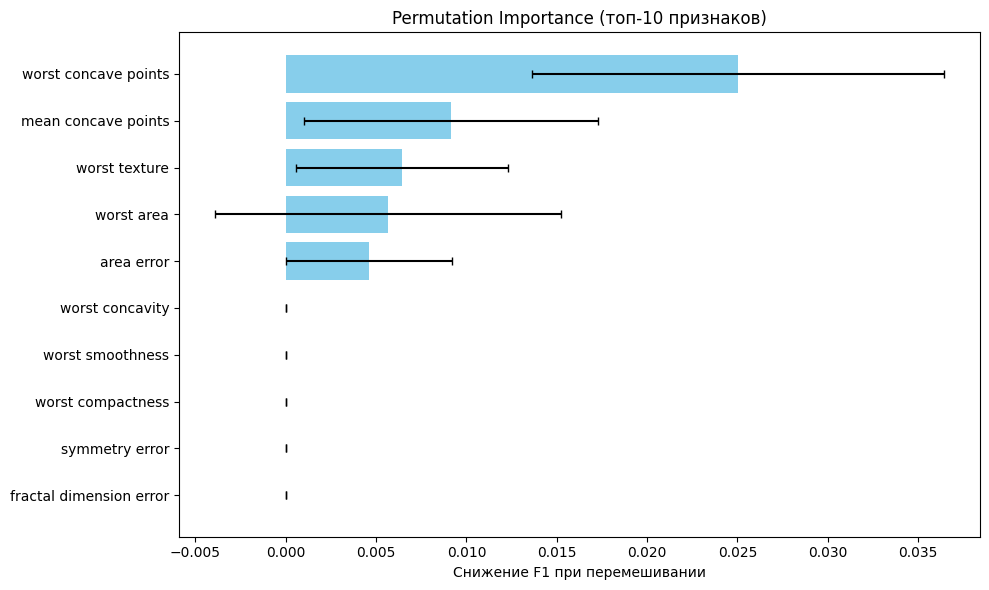

In [8]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_rand_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro')

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
importance_mean = pi_result.importances_mean
importance_std = pi_result.importances_std

sorted_idx = np.argsort(importance_mean)[::-1][:10]
top_features = [feature_names[i] for i in sorted_idx]
top_importances = importance_mean[sorted_idx]
top_stds = importance_std[sorted_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_features, top_importances, xerr=top_stds, capsize=3, color='skyblue')
plt.xlabel('Снижение F1 при перемешивании')
plt.title('Permutation Importance (топ-10 признаков)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_importances = best_rf.feature_importances_
sorted_idx_rf = np.argsort(rf_importances)[::-1]
for i in range(5):
    print(f"{i+1}. {feature_names[sorted_idx_rf[i]]}: {rf_importances[sorted_idx_rf[i]]:.4f}")
# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

1. worst perimeter: 0.2184
2. worst concave points: 0.1853
3. worst area: 0.1465
4. worst radius: 0.1398
5. mean concave points: 0.1171


встроенная важность смещена в пользу численно больших признаков, а PI отражает реальную потерю качества модели. pi основана на ухудшении метрики модели (F1) после случайного перемешивания, учитывает реальный вклад в предсказательную способность модели на тестовых данных. pi надёжнее.

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

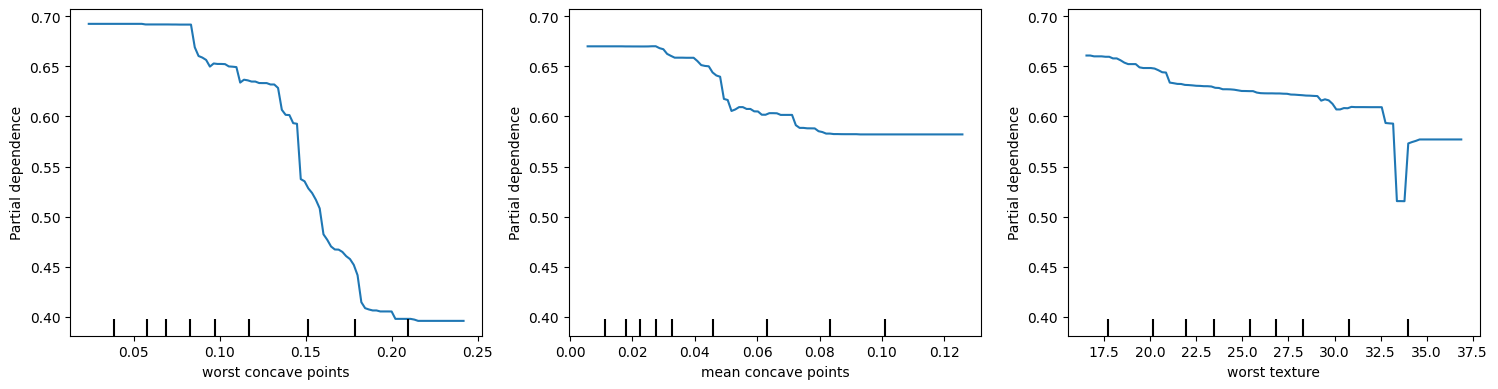

In [10]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = sorted_idx[:3]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train,
    features=top3_idx, 
    kind='average',       # усреднённый PDP (не ICE)
    ax=ax,                # оси для подграфиков
    feature_names=feature_names  # подписи признаков
)
plt.tight_layout()
plt.show()

кривая падает, значит при увеличинии признака(и других фиксированных) падает вероятность класса 1(доброкачественная опухоль). я погуглила, это логично первый и второй отвечают за вогнутость, третий за текстуру, чем хуже текстура, тем хуже опухоль как я понимаю.

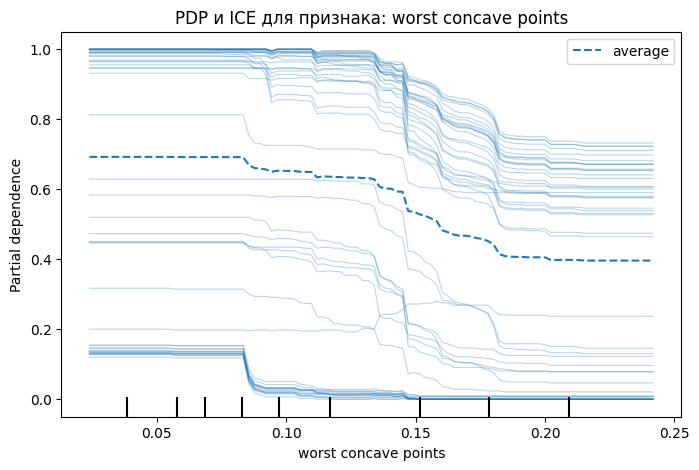

In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
top1_idx = top3_idx[0]

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    best_rf, X_train, features=[top1_idx],
    kind='both',               # PDP + все ICE линии
    ax=ax,
    feature_names=feature_names,
    subsample=50,              # показывать не все 455 объектов, а случайные 50 (график чище)
    random_state=42,
    ice_lines_kw={'alpha': 0.3, 'linewidth': 0.8}  # прозрачность линий
)
ax.set_title(f'PDP и ICE для признака: {feature_names[top1_idx]}')
plt.show()

ICE-кривые для признака worst concave points показывают, что большинство объектов демонстрируют одинаковое направление влияния: с ростом признака вероятность доброкачественности снижается, есть парочку отличающихся - это говорит о том, что эффект признака зависит от других признаков (есть взаимодействия), но в целом эффект дастаточно однороден

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [12]:
!pip show shap

Name: shap
Version: 0.52.0
Summary: A unified approach to explain the output of any machine learning model.
Home-page: 
Author: 
Author-email: Scott Lundberg <slund1@cs.washington.edu>
License: MIT License
Location: C:\MyLEARNING\ML-course-HW\ml-hw\.venv\Lib\site-packages
Requires: cloudpickle, llvmlite, numba, numpy, packaging, pandas, scikit-learn, scipy, slicer, tqdm
Required-by: 


In [13]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf, X_train)
shap_values = explainer.shap_values(X_test)
print("форма shap_values:", shap_values.shape)

Background dataset has 455 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=455 when initializing the masker.


форма shap_values: (114, 30, 2)


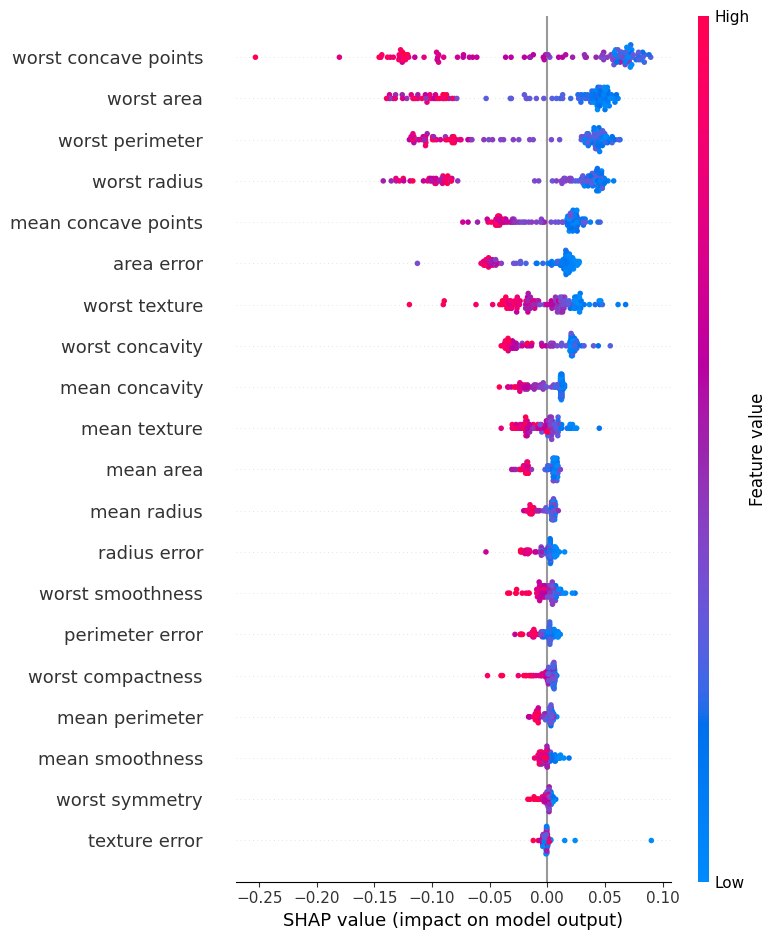

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap_values_class1 = shap_values[:, :, 1]
shap.summary_plot(shap_values_class1, X_test, feature_names=feature_names)

1. Самые важные признаки по shap(для rf) - worst concave points, worst area, worst perimeter
2. В этом датасете много скоррелированных признаков, например worst radius, worst perimeter и worst area. pi выбрал важным  worst area, а worst radius, worst perimeter не попали в топ 10. а shap не ломается от корреляций, распределяет вклад справедливо между признаками, поэтому все три эти в топе. думаю самые важные это те, что попали и там, и там

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


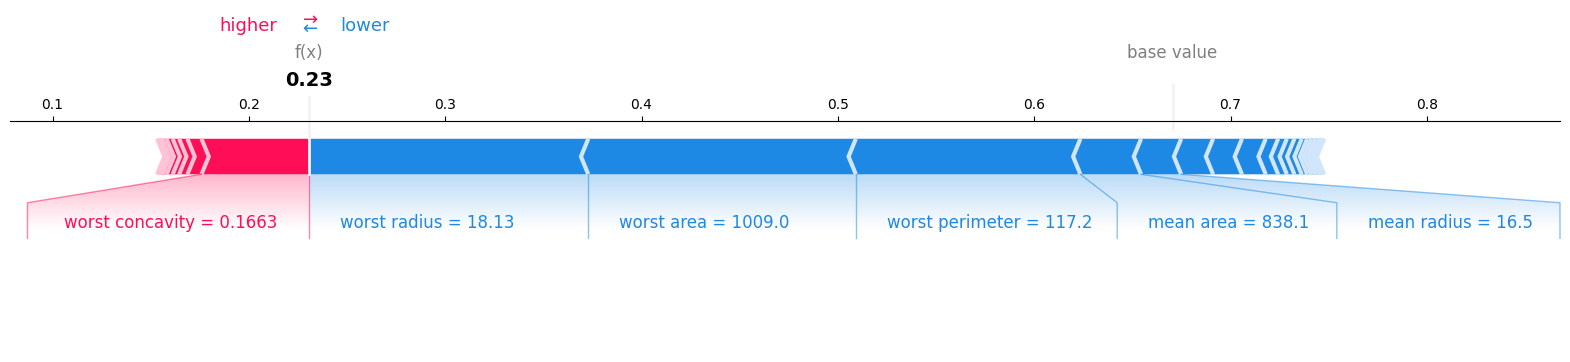

In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
idx = errors[0]
shap_values_class1 = shap_values[:, :, 1]
expected_value = explainer.expected_value[1]  # базовое предсказание для класса 1
shap.force_plot(
    expected_value, 
    shap_values_class1[idx, :], 
    X_test.iloc[idx, :], 
    feature_names=feature_names,
    matplotlib=True  # если True – статический график
)

значит для первого ошибочного объекта виноваты те признаки, что толкают к 0, то есть синие стрелки. это признаки: worst radius, worst area, worst perimeter, mean area и тд

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [17]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

F1-macro на тесте (с утечкой): 1.0

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        72

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



Background dataset has 455 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=455 when initializing the masker.


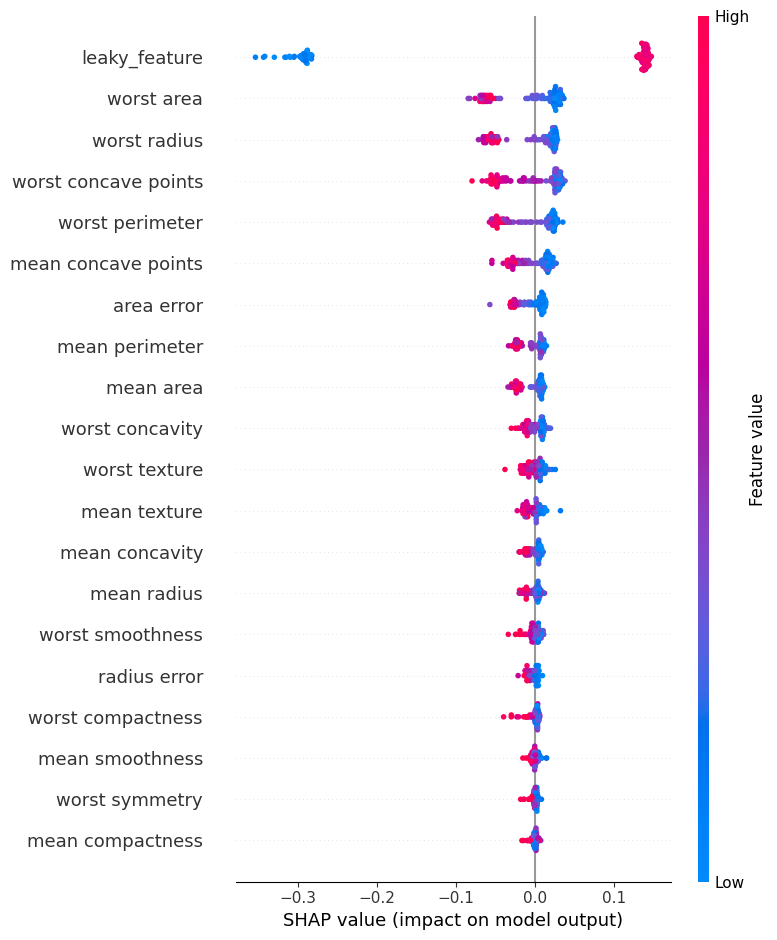

In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(random_state=42, n_estimators=100)
rf_ext.fit(X_train_ext, y_train)

y_pred_ext = rf_ext.predict(X_test_ext)

print("F1-macro на тесте (с утечкой):", f1_score(y_test, y_pred_ext, average='macro'))
print("\nClassification report:")
print(classification_report(y_test, y_pred_ext))

# PI для расширенной модели
pi_ext = permutation_importance(rf_ext, X_test_ext, y_test, n_repeats=10, 
                                random_state=42, scoring='f1_macro')

# SHAP для расширенной модели
explainer_ext = shap.TreeExplainer(rf_ext, X_train_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)
shap_values_ext_class1 = shap_values_ext[:, :, 1]

# summary plot
shap.summary_plot(shap_values_ext_class1, X_test_ext)


а) PI обнаружит leaky_feature как признак с огромным снижением F1 при его перемешивании (намного выше, чем у остальных признаков). Потому что модель полностью полагается на этот признак для предсказания – когда мы его случайно перемешиваем, предсказания становятся случайными, и качество резко падает. метрика на тесте выросла так как с добавлением leaky_feature модель может использовать информацию, которой не должно быть в реальной системе – значения признака на тесте содержат y_test (истинные классы). Это нечестное преимущество: модель просто «считывает» ответ с шумом. Поэтому метрика может подняться до 1.0. Это признак утечки: аномально высокое качество при добавлении «слишком хорошего» признака.
б) SHAP поставил leaky_feature на первое место с огромным разбросом SHAP-значений.
это сигнал утечки
в) если посмотреть на значения SHAP для random_feature, они не будут иметь чёткой цветовой закономерности (красные и синие точки перемешаны). Это указывает на отсутствие связи с таргетом.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [19]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
methods = ['SVM baseline', 'SVM Grid Search', 'RF baseline', 'RF Random Search']

cv_values = [
    f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
    f"{svm_grid_search.best_score_:.4f}",
    f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
    f"{rf_rand_search.best_score_:.4f}"
]

test_f1 = [
    f1_score(y_test, baseline_svm.predict(X_test), average='macro'),
    f1_score(y_test, svm_grid_search.predict(X_test), average='macro'),
    f1_score(y_test, baseline_rf.predict(X_test), average='macro'),
    f1_score(y_test, rf_rand_search.predict(X_test), average='macro')
]

conclusions = [
    'Хорошее качество, стабильно',
    'Незначительное улучшение CV, тест совпадает с baseline',
    'Ниже SVM, но приемлемо',
    'CV улучшился, тест не изменился → возможна переоценка CV'
]

df = pd.DataFrame({'Метод': methods, 'CV F1 (mean±std)': cv_values, 'Test F1': test_f1, 'Выводы': conclusions})
print(df.to_string(index=False))

           Метод CV F1 (mean±std)  Test F1                                                   Выводы
    SVM baseline  0.9694 ± 0.0193 0.981151                              Хорошее качество, стабильно
 SVM Grid Search           0.9786 0.981151   Незначительное улучшение CV, тест совпадает с baseline
     RF baseline  0.9504 ± 0.0255 0.952638                                   Ниже SVM, но приемлемо
RF Random Search           0.9576 0.952638 CV улучшился, тест не изменился → возможна переоценка CV


1. тюнинг не дал значительного прироста
- SVM: Grid Search дал прирост CV F1 с 0.9694 до 0.9786 (+0.0092), но на тесте значение не изменилось (0.9812). Это говорит о том, что baseline SVM уже был близок к оптимуму, а тюнинг лишь немного улучшил кросс-валидационную оценку.
- RandomForest: Random Search повысил CV F1 с 0.9504 до 0.9576 (+0.0072), однако на тесте качество осталось 0.9526.
2. не полностью совпадают, так как корреляция(shap менее подвержен), разная метрика(PI оценивает падение F1-macro, а SHAP усредняет абсолютные вклады в предсказания)
3. пришлось бы отдельно масштабировать признаки для SVM и логистической регрессии, а затем передавать масштабированные данные в модели.
4. думаю этими штуками легко отслеживать утечки, а также отбрасывать неважные признаки. помогло объяснить модель заказчику.

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [20]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")

ModuleNotFoundError: No module named 'optuna'